In [75]:
import numpy as np
import pandas as pd

### Timedelta Objects
> Represents a duration , the difference between two dates or times

In [78]:
#creates using Timestapm objects
t1 = pd.Timestamp('2025, 10, 13')
t2 = pd.Timestamp('2025, 12, 12')
t2 - t1

Timedelta('60 days 00:00:00')

In [80]:
## standalone creation
pd.Timedelta(days=2,hours=2,minutes=30)

Timedelta('2 days 02:30:00')

In [82]:
## arithmetic 
pd.Timestamp(2025, 12, 12) + pd.Timedelta(days=2,hours=2,minutes=30)

Timestamp('2025-12-14 02:30:00')

In [84]:
pd.date_range(start='2025-3-4',end='2025-12-12',freq='D')+pd.Timedelta(days=2,hours=2,minutes=30)

DatetimeIndex(['2025-03-06 02:30:00', '2025-03-07 02:30:00',
               '2025-03-08 02:30:00', '2025-03-09 02:30:00',
               '2025-03-10 02:30:00', '2025-03-11 02:30:00',
               '2025-03-12 02:30:00', '2025-03-13 02:30:00',
               '2025-03-14 02:30:00', '2025-03-15 02:30:00',
               ...
               '2025-12-05 02:30:00', '2025-12-06 02:30:00',
               '2025-12-07 02:30:00', '2025-12-08 02:30:00',
               '2025-12-09 02:30:00', '2025-12-10 02:30:00',
               '2025-12-11 02:30:00', '2025-12-12 02:30:00',
               '2025-12-13 02:30:00', '2025-12-14 02:30:00'],
              dtype='datetime64[ns]', length=284, freq='D')

In [86]:
## with real life example
df = pd.read_csv('deliveries_time.csv')
df.head()

,order_date,delivery_date
0,5/24/98,2/5/99
1,4/22/92,3/6/98
2,2/10/91,8/26/92
3,7/21/92,11/20/97
4,9/2/93,6/10/98


In [88]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])

C:\Users\vikas\AppData\Local\Temp\ipykernel_17160\3472121163.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_date'] = pd.to_datetime(df['order_date'])
C:\Users\vikas\AppData\Local\Temp\ipykernel_17160\3472121163.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['delivery_date'] = pd.to_datetime(df['delivery_date'])


In [90]:
df.head()

,order_date,delivery_date
0,1998-05-24,1999-02-05
1,1992-04-22,1998-03-06
2,1991-02-10,1992-08-26
3,1992-07-21,1997-11-20
4,1993-09-02,1998-06-10


In [92]:
df['delivery_order_period'] = df['delivery_date']-df['order_date']

In [94]:
df.head()

,order_date,delivery_date,delivery_order_period
0,1998-05-24,1999-02-05,257 days
1,1992-04-22,1998-03-06,2144 days
2,1991-02-10,1992-08-26,563 days
3,1992-07-21,1997-11-20,1948 days
4,1993-09-02,1998-06-10,1742 days


In [96]:
df['delivery_order_period'].mean()

Timedelta('1217 days 22:53:53.532934128')

### Time series
> A time series is a data set that tracks a sample over time. In particular, a time series allows one to see what factors influence certain variables from period to period. Time series analysis can be useful to see how a given asset, security, or economic variable changes over time.
### Examples
* Financial Data (Company stocks)
* Natural Data (Rainfall measurement)
* Event Data (Covid)
* Medical Data (Heart rate monitoring)
#### Types of Operations done on Time Series
* Time Series Analysis
* Time Series Forecasting

In [99]:
google = pd.read_csv('google.csv')
google

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361
1,2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874
2,2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897
3,2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808
4,2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276
...,...,...,...,...,...,...,...
4466,2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100
4467,2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800
4468,2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100
4469,2022-05-19,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600


In [101]:
google['Date']=pd.to_datetime(google['Date'])

In [124]:
google.set_index(google['Date'],inplace=True)

In [126]:
google.head()

,Date,Open,High,Low,Close,Adj Close,Volume,month_name,day_name,quarter
Date,,,,,,,,,,
2004-08-19,2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-20,2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
2004-08-23,2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897,August,Monday,3
2004-08-24,2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808,August,Tuesday,3
2004-08-25,2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276,August,Wednesday,3


In [107]:
## fetch a specific date
google.loc['2020-02-05']

Date         2020-02-05 00:00:00
Open                 1462.420044
High                 1463.839966
Low                  1430.560059
Close                 1448.22998
Adj Close             1448.22998
Volume                   1986200
Name: 2020-02-05 00:00:00, dtype: object

In [109]:
## partial indexing --> select aparticular year/ month
google.loc['2020-12']

,Date,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,,
2020-12-01,2020-12-01,1774.369995,1824.829956,1769.369995,1798.099976,1798.099976,1736900
2020-12-02,2020-12-02,1798.099976,1835.650024,1789.473022,1827.949951,1827.949951,1222000
2020-12-03,2020-12-03,1824.010010,1847.199951,1822.650024,1826.770020,1826.770020,1227300
2020-12-04,2020-12-04,1824.520020,1833.160034,1816.989990,1827.989990,1827.989990,1378200
2020-12-07,2020-12-07,1819.000000,1832.369995,1805.780029,1819.479980,1819.479980,1320900
2020-12-08,2020-12-08,1810.099976,1821.900024,1796.204956,1818.550049,1818.550049,1096300
2020-12-09,2020-12-09,1812.010010,1834.270020,1767.810059,1784.130005,1784.130005,1507600
2020-12-10,2020-12-10,1769.800049,1781.310059,1740.319946,1775.329956,1775.329956,1362800
2020-12-11,2020-12-11,1763.060059,1784.449951,1760.000000,1781.770020,1781.770020,1220700


In [111]:
google.loc['2020']

,Date,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,,
2020-01-02,2020-01-02,1341.550049,1368.140015,1341.550049,1367.369995,1367.369995,1406600
2020-01-03,2020-01-03,1347.859985,1372.500000,1345.543945,1360.660034,1360.660034,1186400
2020-01-06,2020-01-06,1350.000000,1396.500000,1350.000000,1394.209961,1394.209961,1732300
2020-01-07,2020-01-07,1397.939941,1402.989990,1390.380005,1393.339966,1393.339966,1502700
2020-01-08,2020-01-08,1392.079956,1411.579956,1390.839966,1404.319946,1404.319946,1528000
...,...,...,...,...,...,...,...
2020-12-24,2020-12-24,1735.000000,1746.000000,1729.109985,1738.849976,1738.849976,346800
2020-12-28,2020-12-28,1751.635010,1790.728027,1746.334961,1776.089966,1776.089966,1393000
2020-12-29,2020-12-29,1787.790039,1792.439941,1756.089966,1758.719971,1758.719971,1299400


In [113]:
## crete year month-name and day-name
# google['month_name'] = google['Date'].dt.month_name()
# google['day_name'] = google['Date'].dt.day_name()
# google['quarter'] = google['Date'].dt.quarter

In [115]:
google.head()

,Date,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,,
2004-08-19,2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361
2004-08-20,2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874
2004-08-23,2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897
2004-08-24,2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808
2004-08-25,2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276


In [118]:
google['month_name'] = google.index.month_name()
google['day_name'] = google.index.day_name()
google['quarter'] = google.index.quarter

In [120]:
google.head()

,Date,Open,High,Low,Close,Adj Close,Volume,month_name,day_name,quarter
Date,,,,,,,,,,
2004-08-19,2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-20,2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
2004-08-23,2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897,August,Monday,3
2004-08-24,2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808,August,Tuesday,3
2004-08-25,2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276,August,Wednesday,3


In [136]:
## challenge -> fetch info for a particular date every year -> limitation of timedelta
dt = pd.date_range(start='2005-1-6',end='2020-1-6',freq=pd.DateOffset(years=1))
google[google.index.isin(dt)]

,Date,Open,High,Low,Close,Adj Close,Volume,month_name,day_name,quarter
Date,,,,,,,,,,
2005-01-06,2005-01-06,97.175758,97.584229,93.509506,93.922951,93.922951,20852067,January,Thursday,1
2006-01-06,2006-01-06,227.581970,234.371521,225.773743,231.960556,231.960556,35646914,January,Friday,1
2009-01-06,2009-01-06,165.868286,169.763687,162.585587,166.406265,166.406265,12898566,January,Tuesday,1
2010-01-06,2010-01-06,311.761444,311.761444,302.047852,302.994293,302.994293,7987226,January,Wednesday,1
2011-01-06,2011-01-06,304.199799,308.060303,303.885956,305.604523,305.604523,4131026,January,Thursday,1
2012-01-06,2012-01-06,328.344299,328.767700,323.681763,323.796326,323.796326,5405987,January,Friday,1
2014-01-06,2014-01-06,554.426880,557.340942,551.154114,556.573853,556.573853,3551864,January,Monday,1
2015-01-06,2015-01-06,513.589966,514.761719,499.678131,500.585632,500.585632,2899940,January,Tuesday,1
2016-01-06,2016-01-06,730.000000,747.179993,728.919983,743.619995,743.619995,1947000,January,Wednesday,1


<Axes: xlabel='Date'>

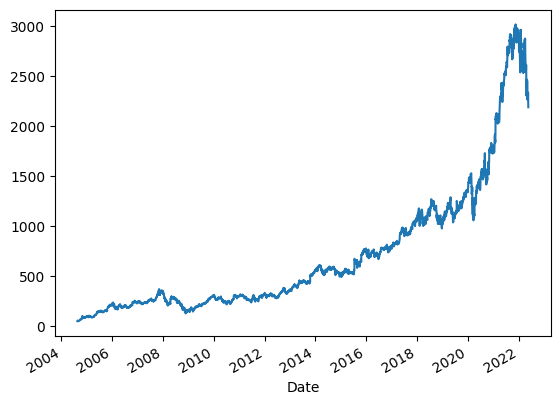

In [138]:
## visualise a single col
google['Close'].plot()

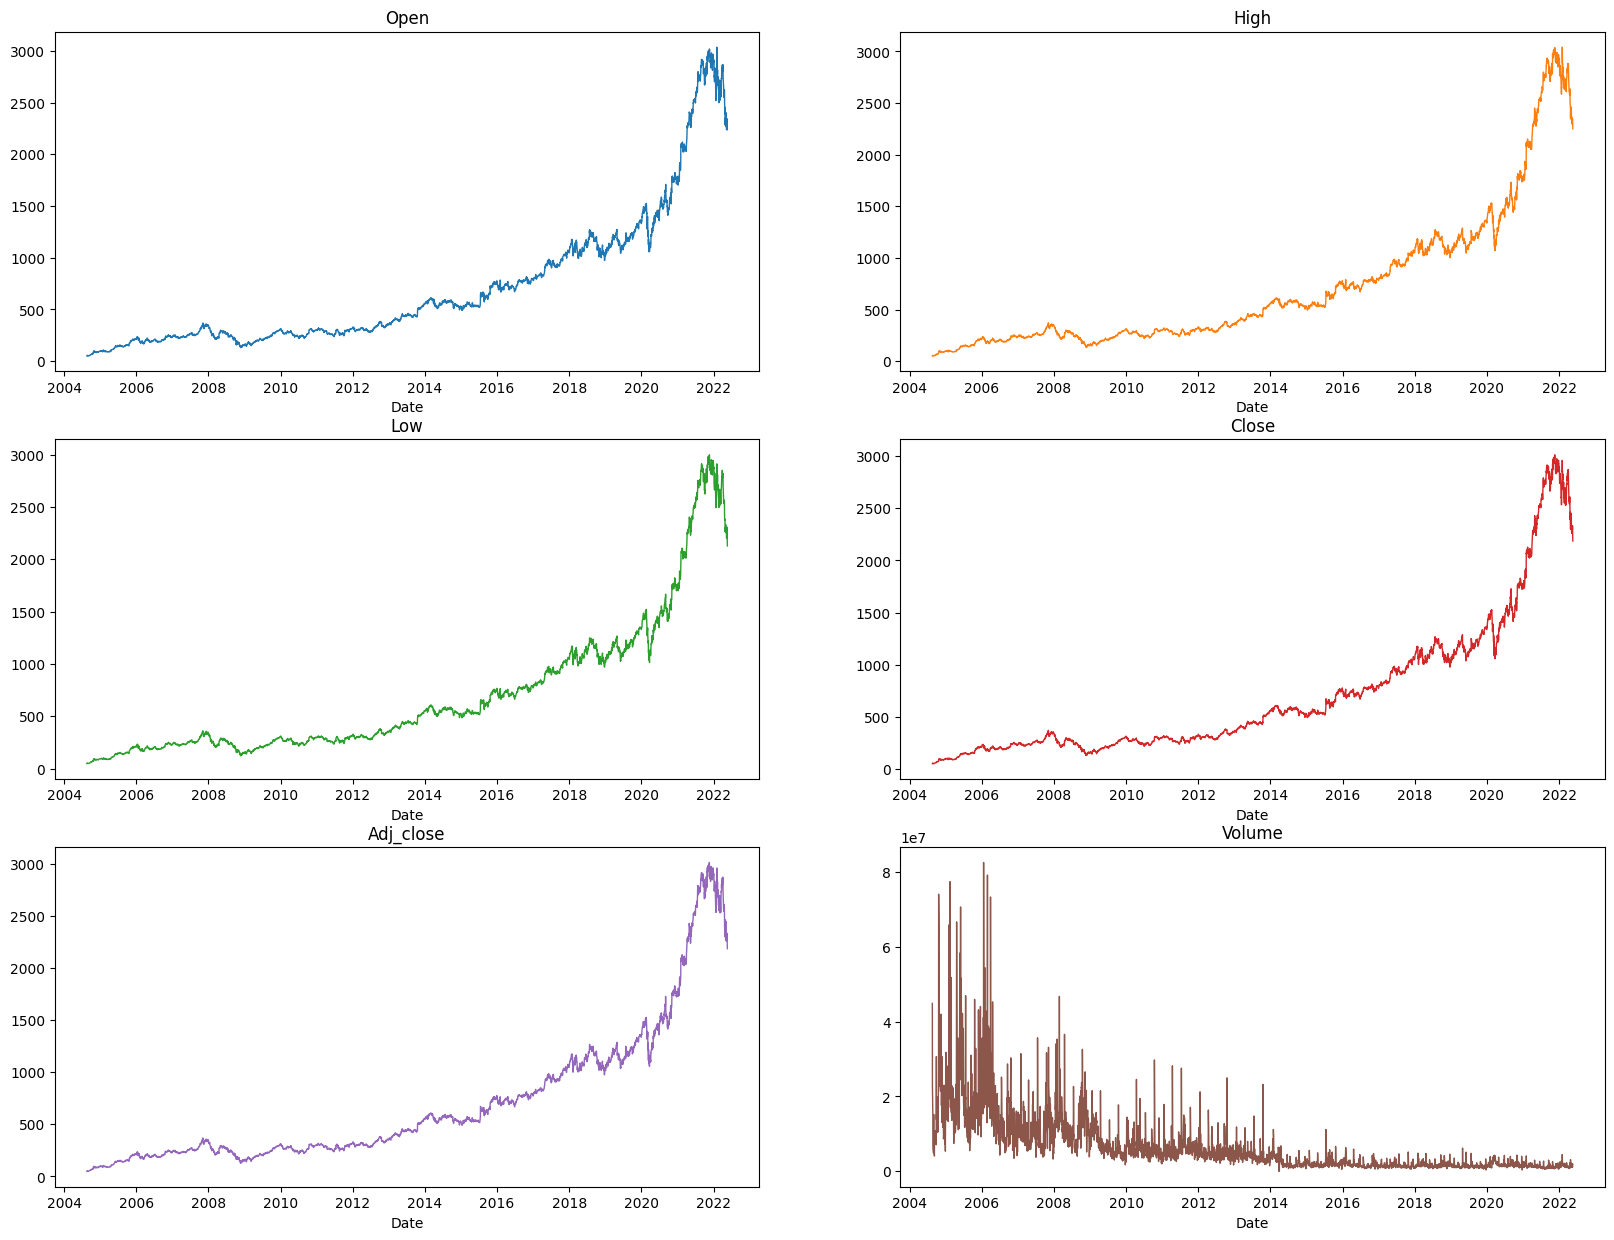

In [144]:
## viz all columns together
google_df = google[['Open','High','Low','Close','Adj Close','Volume']]
ax = google_df.plot(
    subplots=True,
    layout=(3,2),
    sharex=False,
    sharey=False,
    linewidth=1,
    fontsize=10,
    legend=False,
    figsize=(20,15),
    title=['Open','High','Low','Close','Adj_close','Volume']
)

<Axes: xlabel='Date'>

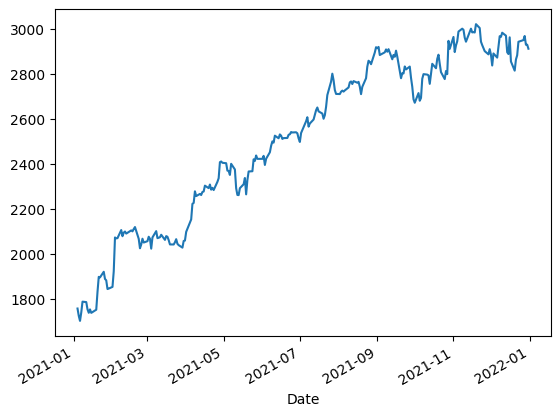

In [160]:
## plot for a particular year / month /  week
google.loc['2021']['Open'].plot()

<Axes: xlabel='Date'>

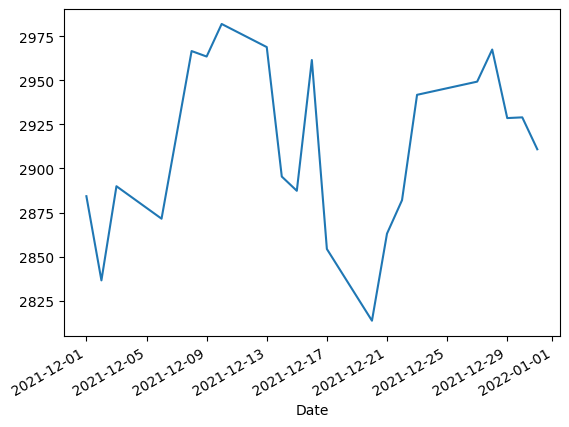

In [162]:
google.loc['2021-12']['Open'].plot()

<Axes: xlabel='Date'>

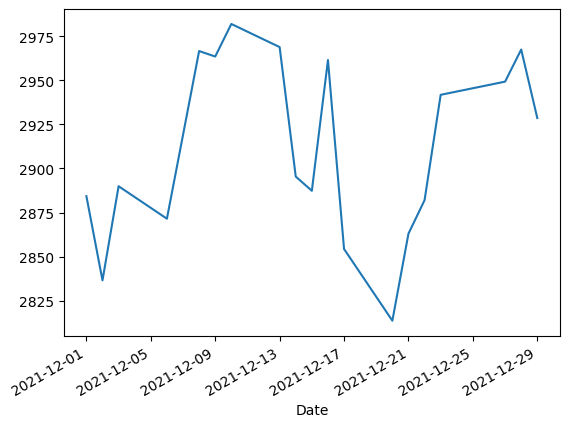

In [166]:
google.loc['2021-12-01':'2021-12-29']['Open'].plot()

<Axes: xlabel='month_name'>

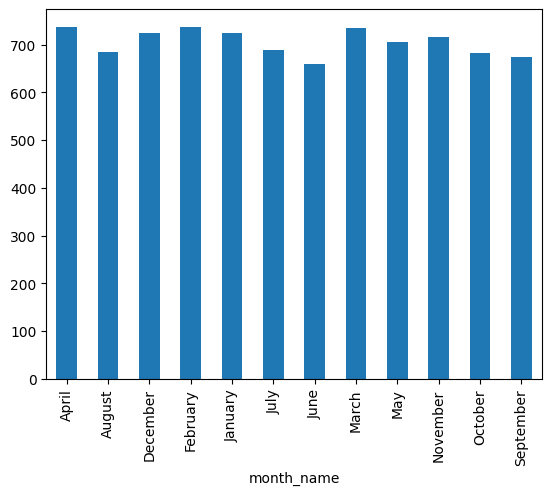

In [168]:
## monthly trend 
google.groupby('month_name')['Open'].mean().plot(kind='bar')

<Axes: xlabel='day_name'>

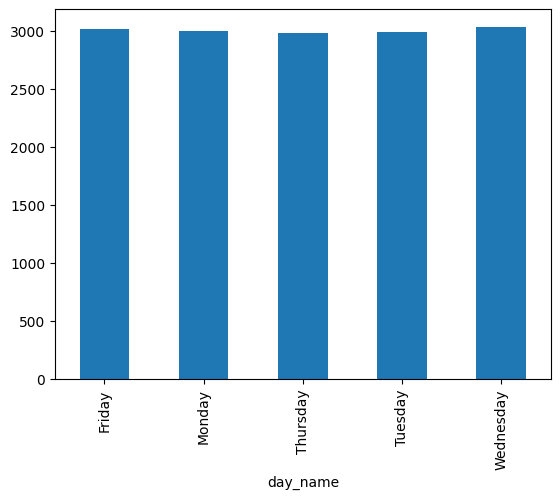

In [172]:
## weekened trend
google.groupby('day_name')['Open'].max().plot(kind='bar')

<Axes: xlabel='quarter'>

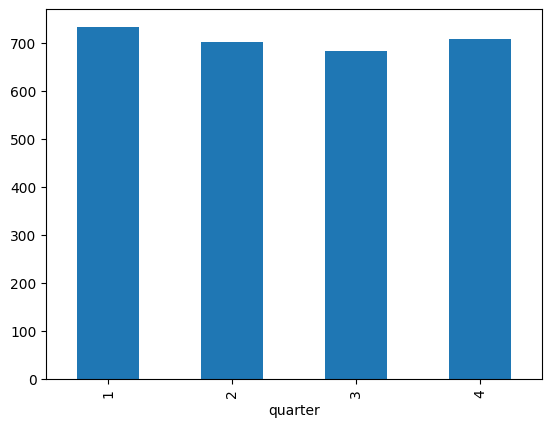

In [174]:
## quarterly trend
google.groupby('quarter')['Open'].mean().plot(kind='bar')

In [176]:
## frequency
google.index

DatetimeIndex(['2004-08-19', '2004-08-20', '2004-08-23', '2004-08-24',
               '2004-08-25', '2004-08-26', '2004-08-27', '2004-08-30',
               '2004-08-31', '2004-09-01',
               ...
               '2022-05-09', '2022-05-10', '2022-05-11', '2022-05-12',
               '2022-05-13', '2022-05-16', '2022-05-17', '2022-05-18',
               '2022-05-19', '2022-05-20'],
              dtype='datetime64[ns]', name='Date', length=4471, freq=None)

In [194]:
## asfreq()
google.asfreq('D')
google.asfreq('B')
google.asfreq('QE')
google.asfreq('YE')
google.asfreq('ME')
google.asfreq('6h')
google.asfreq('6h',method='ffill')

,Date,Open,High,Low,Close,Adj Close,Volume,month_name,day_name,quarter
Date,,,,,,,,,,
2004-08-19 00:00:00,2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-19 06:00:00,2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-19 12:00:00,2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-19 18:00:00,2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-20 00:00:00,2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
...,...,...,...,...,...,...,...,...,...,...
2022-05-19 00:00:00,2022-05-19,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600,May,Thursday,2
2022-05-19 06:00:00,2022-05-19,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600,May,Thursday,2
2022-05-19 12:00:00,2022-05-19,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600,May,Thursday,2


## Resampling
> Resampling involves changing the frequency of your time series observations.
#### Two types of resampling are:
* `Upsampling:` Where you increase the frequency of the samples, such as from minutes to seconds.
* `Downsampling:` Where you decrease the frequency of the samples, such as from days to months.

<Axes: xlabel='Date'>

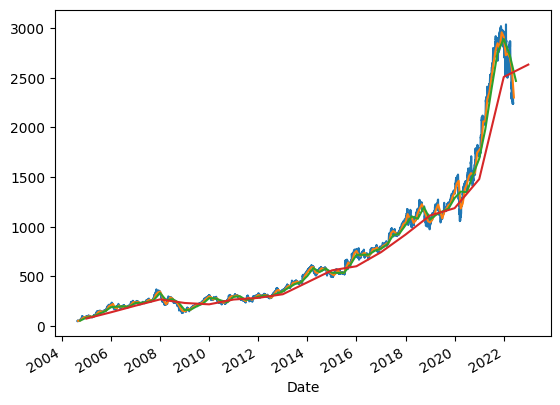

In [209]:
## downsampling
google['Open'].plot()
google['Open'].resample('ME').mean().plot()
google['Open'].resample('QE').mean().plot()
google['Open'].resample('YE').mean().plot()

<Axes: xlabel='Date'>

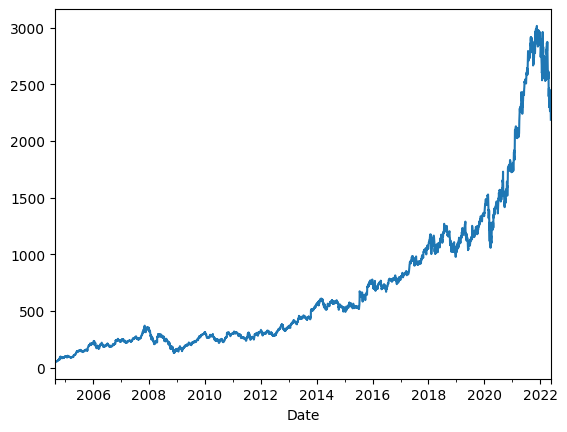

In [217]:
## upsamplong
## interpolate --> to fill null values
google['Close'].resample('6h').interpolate(method='linear').plot()

## Rolling Window(Smoothing)
> Time series data in original format can be quite volatile, especially on smaller aggregation levels. The concept of rolling, or moving averages is a useful technique for smoothing time series data.

<Axes: xlabel='Date'>

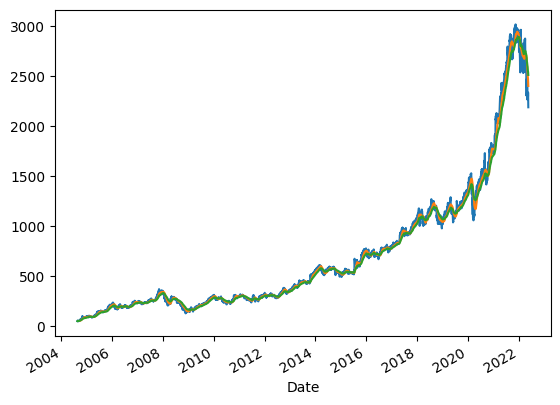

In [233]:
## rolling window
google['Close'].plot()
google['Close'].rolling(30).mean().plot()
google['Close'].ewm(30).mean().plot()

### Shifting
> the shift() function in pandas is used to , well , shift the entire series up or down by the desired number of periods

In [242]:
## shift()
google['Open'].shift(1)
google['Open'].shift(2)
google['Open'].shift(-1)
google['Open'].shift(-2)

Date
2004-08-19      55.168217
2004-08-20      55.412300
2004-08-23      52.284027
2004-08-24      52.279045
2004-08-25      53.848164
                 ...     
2022-05-16    2304.750000
2022-05-17    2236.820068
2022-05-18    2241.709961
2022-05-19            NaN
2022-05-20            NaN
Name: Open, Length: 4471, dtype: float64

In [252]:
## example
login = pd.read_csv('login.csv',header=None)
df = login[[1,2]]
user = df.rename(columns={1:'user_id',2:'date_time'})
user.head()

,user_id,date_time
0,466,2017-01-07 18:24:07
1,466,2017-01-07 18:24:55
2,458,2017-01-07 18:25:18
3,458,2017-01-07 18:26:21
4,592,2017-01-07 19:09:59


In [254]:
user['date_time'] = pd.to_datetime(user['date_time'])

In [268]:
user['shifted'] = user['date_time'].shift(1)
user['time_diff'] = user['date_time'] - user['shifted']
user.groupby('user_id')['time_diff'].mean().mean()

Timedelta('0 days 02:44:25.545418753')

In [266]:
user['user_id'].value_counts()

user_id
413     222
458     208
492     162
882     140
592     122
       ... 
1043      1
1045      1
1047      1
1048      1
880       1
Name: count, Length: 433, dtype: int64